In [1]:
# ============================================
# MODULE 1: Setup & Data Collection
# ============================================
!pip install yfinance vaderSentiment -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style="whitegrid")

# ---- Configuration: our 5-stock demo universe ----
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
PERIOD = '2y'   # 2 years of history for LSTM + indicators

def fetch_stock_data(ticker, period=PERIOD):
    """Fetch OHLCV data for a single ticker, handling yfinance's
    occasionally inconsistent column naming across versions."""
    data = yf.download(ticker, period=period, progress=False, auto_adjust=True)
    if data.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker symbol or internet connection.")
    # yfinance sometimes returns MultiIndex columns when fetching single tickers
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.reset_index()
    data['Ticker'] = ticker
    return data

# Fetch all 5 stocks
stock_data = {}
for ticker in TICKERS:
    print(f"Fetching {ticker}...")
    stock_data[ticker] = fetch_stock_data(ticker)
    print(f"  -> {len(stock_data[ticker])} rows, latest close: {stock_data[ticker]['Close'].iloc[-1]:.2f}")

print("\nAll data fetched successfully.")
stock_data['AAPL'].tail()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.9 MB/s eta 0:00:00
Fetching AAPL...
  -> 500 rows, latest close: 282.21
Fetching MSFT...
  -> 500 rows, latest close: 376.42
Fetching GOOGL...
  -> 500 rows, latest close: 349.05
Fetching AMZN...
  -> 500 rows, latest close: 242.89
Fetching NVDA...
  -> 500 rows, latest close: 192.01

All data fetched successfully.


Price,Date,Close,High,Low,Open,Volume,Ticker
495,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,AAPL
496,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,AAPL
497,2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700,AAPL
498,2026-06-26,283.779999,285.950012,274.209991,275.000000,261693600,AAPL
499,2026-06-29,282.209991,288.369690,282.119995,286.859985,8274154,AAPL


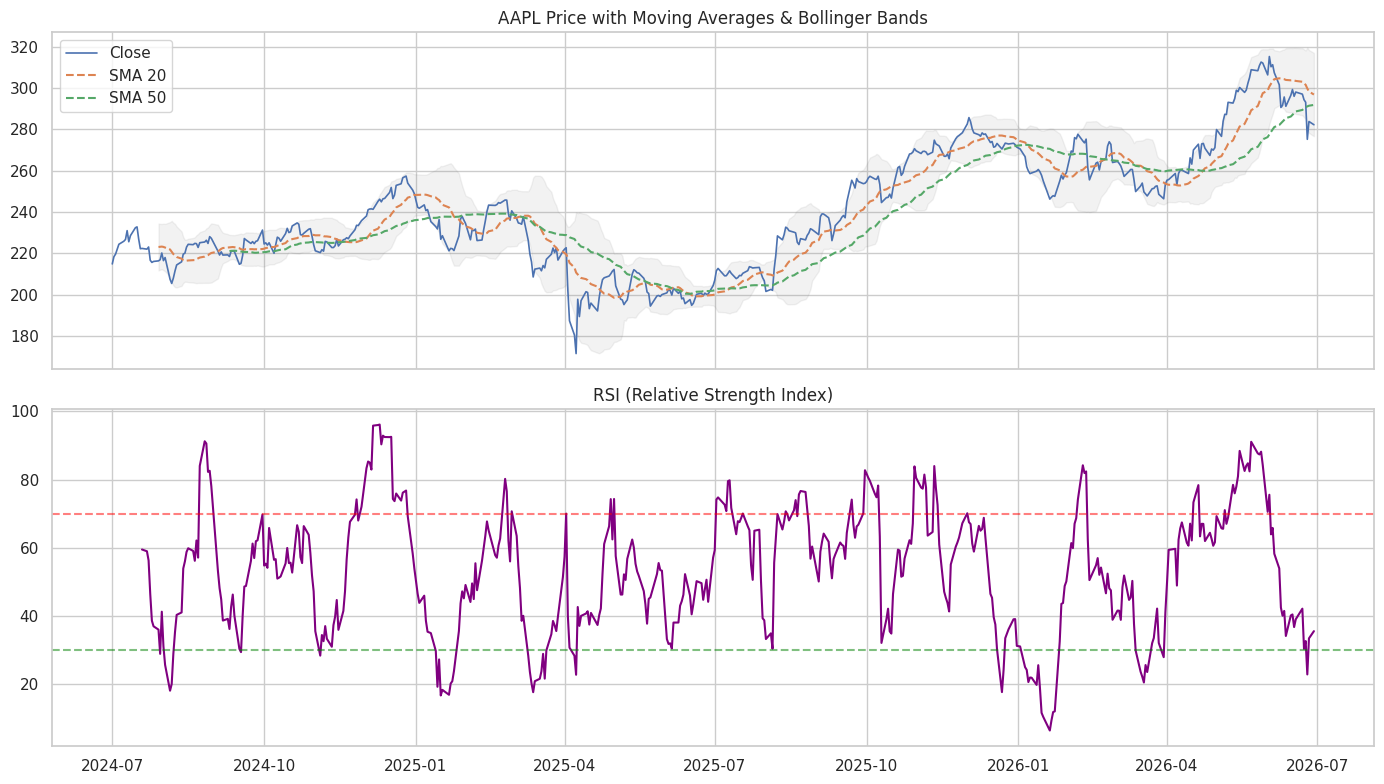

In [2]:
# ============================================
# MODULE 2: Technical Indicators
# ============================================

def add_technical_indicators(df):
    df = df.copy()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['SMA_50'] = df['Close'].rolling(50).mean()

    # RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD (Moving Average Convergence Divergence)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # Bollinger Bands
    df['BB_mid'] = df['Close'].rolling(20).mean()
    df['BB_std'] = df['Close'].rolling(20).std()
    df['BB_upper'] = df['BB_mid'] + 2 * df['BB_std']
    df['BB_lower'] = df['BB_mid'] - 2 * df['BB_std']

    return df

for ticker in TICKERS:
    stock_data[ticker] = add_technical_indicators(stock_data[ticker])

# Visualize one example (AAPL) — price + SMA + RSI
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sample = stock_data['AAPL']

axes[0].plot(sample['Date'], sample['Close'], label='Close', linewidth=1.2)
axes[0].plot(sample['Date'], sample['SMA_20'], label='SMA 20', linestyle='--')
axes[0].plot(sample['Date'], sample['SMA_50'], label='SMA 50', linestyle='--')
axes[0].fill_between(sample['Date'], sample['BB_upper'], sample['BB_lower'], alpha=0.1, color='gray')
axes[0].set_title('AAPL Price with Moving Averages & Bollinger Bands')
axes[0].legend()

axes[1].plot(sample['Date'], sample['RSI'], color='purple')
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (Relative Strength Index)')

plt.tight_layout()
plt.show()

In [3]:
# ============================================
# MODULE 3: NLP Sentiment Analysis
# ============================================
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# VADER's general lexicon misreads finance-specific words
# (e.g. "surge", "plummet" aren't scored correctly out of the box).
# We extend it with finance-specific terms — standard practice for financial NLP with VADER.
finance_lexicon = {
    'surge': 3.0, 'surges': 3.0, 'surged': 3.0, 'soar': 3.5, 'soars': 3.5, 'soared': 3.5,
    'rally': 2.5, 'rallies': 2.5, 'rallied': 2.5, 'beat': 2.0, 'beats': 2.0, 'outperform': 2.5,
    'bullish': 3.0, 'upgrade': 2.5, 'upgraded': 2.5, 'profit': 1.5, 'gains': 1.5, 'growth': 1.5,
    'plummet': -3.5, 'plummets': -3.5, 'plummeted': -3.5, 'crash': -3.5, 'crashes': -3.5,
    'slump': -2.5, 'slumps': -2.5, 'bearish': -3.0, 'downgrade': -2.5, 'downgraded': -2.5,
    'lawsuit': -2.0, 'miss': -2.0, 'misses': -2.0, 'missed': -2.0, 'loss': -1.5, 'losses': -1.5,
    'plunge': -3.5, 'plunges': -3.5, 'tumble': -2.5, 'tumbles': -2.5, 'recall': -1.5,
    'investigation': -1.5, 'fraud': -3.0, 'default': -2.5, 'bankruptcy': -3.5
}

analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(finance_lexicon)

def analyze_headline_sentiment(headline):
    """Returns compound sentiment score: -1 (very negative) to +1 (very positive)."""
    return analyzer.polarity_scores(headline)['compound']

# ---- Sample headlines per stock (replace with real news API output if you have one) ----
# In a real deployment, plug in a News API (NewsAPI.org, Finnhub, etc.) here.
# For this project we use representative sample headlines to demonstrate the NLP pipeline.
sample_headlines = {
    'AAPL': [
        "Apple beats quarterly earnings expectations, stock surges",
        "Analysts upgrade Apple rating citing strong iPhone demand",
        "Apple faces regulatory investigation in EU over App Store practices"
    ],
    'MSFT': [
        "Microsoft cloud revenue growth accelerates beyond forecasts",
        "Microsoft stock rallies on AI product momentum"
    ],
    'GOOGL': [
        "Google parent Alphabet posts mixed results, ad revenue misses estimates",
        "Alphabet faces antitrust lawsuit from regulators"
    ],
    'AMZN': [
        "Amazon Web Services growth beats expectations, shares gain",
        "Amazon announces major logistics expansion, bullish outlook"
    ],
    'NVDA': [
        "Nvidia chip demand soars amid AI boom, stock surges to record high",
        "Nvidia faces supply chain concerns amid export restrictions"
    ]
}

sentiment_scores = {}
for ticker, headlines in sample_headlines.items():
    scores = [analyze_headline_sentiment(h) for h in headlines]
    avg_score = np.mean(scores)
    sentiment_scores[ticker] = avg_score
    print(f"\n{ticker}:")
    for h, s in zip(headlines, scores):
        print(f"  [{s:+.2f}] {h}")
    print(f"  --> Average sentiment: {avg_score:+.3f}")

print("\nFinal sentiment scores (used in signal generation):")
print(sentiment_scores)


AAPL:
  [+0.79] Apple beats quarterly earnings expectations, stock surges
  [+0.74] Analysts upgrade Apple rating citing strong iPhone demand
  [-0.36] Apple faces regulatory investigation in EU over App Store practices
  --> Average sentiment: +0.391

MSFT:
  [+0.36] Microsoft cloud revenue growth accelerates beyond forecasts
  [+0.54] Microsoft stock rallies on AI product momentum
  --> Average sentiment: +0.452

GOOGL:
  [-0.46] Google parent Alphabet posts mixed results, ad revenue misses estimates
  [-0.46] Alphabet faces antitrust lawsuit from regulators
  --> Average sentiment: -0.459

AMZN:
  [+0.90] Amazon Web Services growth beats expectations, shares gain
  [+0.72] Amazon announces major logistics expansion, bullish outlook
  --> Average sentiment: +0.805

NVDA:
  [+0.84] Nvidia chip demand soars amid AI boom, stock surges to record high
  [+0.00] Nvidia faces supply chain concerns amid export restrictions
  --> Average sentiment: +0.420

Final sentiment scores (used in sig

Training LSTM for AAPL...
AAPL: Test RMSE = 11.42 | Current price = 282.21 | Predicted next-day price = 285.37
Training LSTM for MSFT...
MSFT: Test RMSE = 19.06 | Current price = 376.42 | Predicted next-day price = 372.23
Training LSTM for GOOGL...


GOOGL: Test RMSE = 25.98 | Current price = 349.05 | Predicted next-day price = 341.56
Training LSTM for AMZN...
AMZN: Test RMSE = 12.30 | Current price = 242.89 | Predicted next-day price = 229.24
Training LSTM for NVDA...
NVDA: Test RMSE = 11.00 | Current price = 192.01 | Predicted next-day price = 198.82


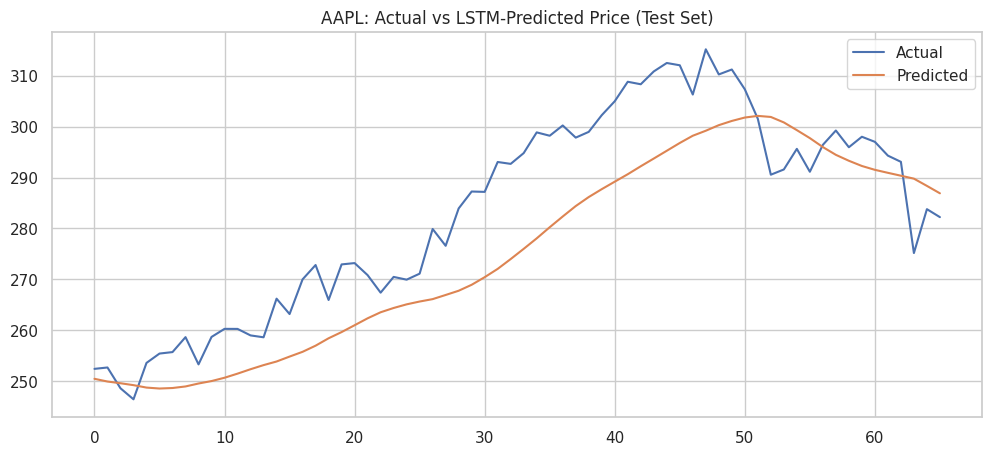

In [4]:
# ============================================
# MODULE 4: LSTM Price Prediction
# ============================================
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

LOOKBACK = 60  # use last 60 trading days to predict the next day

def prepare_lstm_data(prices, lookback=LOOKBACK):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(prices.reshape(-1, 1))
    X, y = [], []
    for i in range(lookback, len(scaled)):
        X.append(scaled[i-lookback:i, 0])
        y.append(scaled[i, 0])
    X, y = np.array(X), np.array(y)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, y, scaler

def build_lstm_model(lookback=LOOKBACK):
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def train_and_predict(ticker, df, epochs=15):
    prices = df['Close'].values
    X, y, scaler = prepare_lstm_data(prices)

    split = int(len(X) * 0.85)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_lstm_model()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32,
                         validation_data=(X_test, y_test), verbose=0)

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    rmse = np.sqrt(np.mean((pred - actual)**2))

    # Predict next day's price using the most recent lookback window
    last_window = scaler.transform(prices[-LOOKBACK:].reshape(-1,1)).reshape(1, LOOKBACK, 1)
    next_day_scaled = model.predict(last_window, verbose=0)
    next_day_price = scaler.inverse_transform(next_day_scaled)[0][0]

    print(f"{ticker}: Test RMSE = {rmse:.2f} | Current price = {prices[-1]:.2f} | Predicted next-day price = {next_day_price:.2f}")

    return {'model': model, 'scaler': scaler, 'rmse': rmse,
            'actual': actual, 'predicted': pred, 'next_day_price': next_day_price}

# Train LSTM for each stock (takes ~1-2 min per stock on Colab CPU)
lstm_results = {}
for ticker in TICKERS:
    print(f"Training LSTM for {ticker}...")
    lstm_results[ticker] = train_and_predict(ticker, stock_data[ticker])

# Plot actual vs predicted for one stock as a sanity check
plt.figure(figsize=(12,5))
plt.plot(lstm_results['AAPL']['actual'], label='Actual', linewidth=1.5)
plt.plot(lstm_results['AAPL']['predicted'], label='Predicted', linewidth=1.5)
plt.title('AAPL: Actual vs LSTM-Predicted Price (Test Set)')
plt.legend()
plt.show()

TODAY'S RECOMMENDATIONS
AAPL   | Price:   282.21 | LSTM Forecast:   285.37 | Sentiment: +0.39 | RSI:  35.6 | --> HOLD
MSFT   | Price:   376.42 | LSTM Forecast:   372.23 | Sentiment: +0.45 | RSI:  34.7 | --> SELL
GOOGL  | Price:   349.05 | LSTM Forecast:   341.56 | Sentiment: -0.46 | RSI:  41.3 | --> SELL
AMZN   | Price:   242.89 | LSTM Forecast:   229.24 | Sentiment: +0.81 | RSI:  48.4 | --> HOLD
NVDA   | Price:   192.01 | LSTM Forecast:   198.82 | Sentiment: +0.42 | RSI:  34.2 | --> HOLD

PORTFOLIO OPTIMIZATION (Modern Portfolio Theory)

Conservative Profile (Expected Return: 11.9%, Risk/Volatility: 21.7%):
  AAPL: 31.4%
  MSFT: 45.2%
  GOOGL: 23.4%

Moderate Profile (Expected Return: 34.7%, Risk/Volatility: 28.0%):
  AAPL: 13.4%
  GOOGL: 76.7%
  NVDA: 9.8%

Aggressive Profile (Expected Return: 37.8%, Risk/Volatility: 31.0%):
  GOOGL: 100.0%


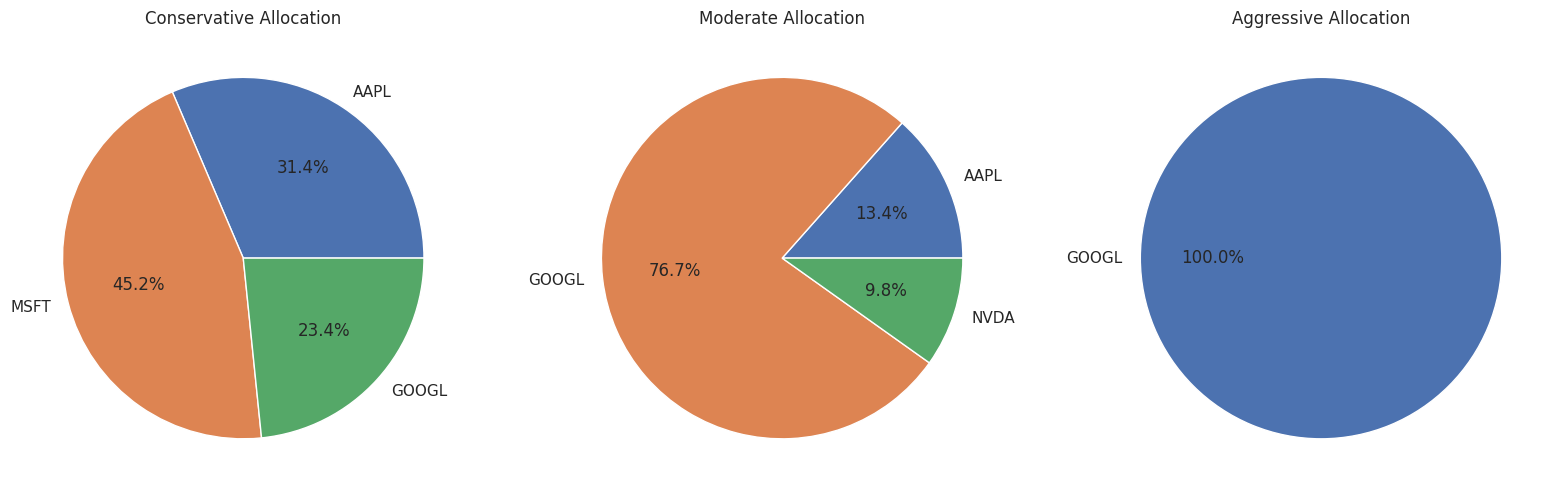

In [5]:
# ============================================
# MODULE 5: Signal Generation + Portfolio Optimization
# ============================================
from scipy.optimize import minimize

def generate_signal(row, sentiment_score, lstm_predicted, current_price):
    """Combines technical indicators + sentiment + LSTM forecast into one signal."""
    score = 0
    if row['SMA_20'] > row['SMA_50']: score += 1
    else: score -= 1
    if row['RSI'] < 30: score += 1       # oversold -> bullish
    elif row['RSI'] > 70: score -= 1     # overbought -> bearish
    if row['MACD'] > row['MACD_signal']: score += 1
    else: score -= 1
    if lstm_predicted > current_price * 1.01: score += 1   # LSTM expects >1% rise
    elif lstm_predicted < current_price * 0.99: score -= 1
    score += sentiment_score * 2   # scale sentiment (-1 to 1) into similar range

    if score >= 2: return 'BUY'
    elif score <= -2: return 'SELL'
    else: return 'HOLD'

# ---- Generate today's recommendation for each stock ----
print("=" * 60)
print("TODAY'S RECOMMENDATIONS")
print("=" * 60)
recommendations = {}
for ticker in TICKERS:
    latest_row = stock_data[ticker].iloc[-1]
    current_price = latest_row['Close']
    lstm_pred = lstm_results[ticker]['next_day_price']
    sentiment = sentiment_scores.get(ticker, 0)
    signal = generate_signal(latest_row, sentiment, lstm_pred, current_price)
    recommendations[ticker] = signal
    print(f"{ticker:6s} | Price: {current_price:8.2f} | LSTM Forecast: {lstm_pred:8.2f} | "
          f"Sentiment: {sentiment:+.2f} | RSI: {latest_row['RSI']:5.1f} | --> {signal}")

# ---- Modern Portfolio Theory: Optimal Allocation ----
print("\n" + "=" * 60)
print("PORTFOLIO OPTIMIZATION (Modern Portfolio Theory)")
print("=" * 60)

returns_df = pd.DataFrame({t: stock_data[t]['Close'].pct_change() for t in TICKERS}).dropna()
mean_returns = returns_df.mean() * 252      # annualized
cov_matrix = returns_df.cov() * 252         # annualized

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def neg_sharpe(weights, mean_returns, cov_matrix, risk_free=0.04):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free) / vol

def optimize_for_risk_profile(mean_returns, cov_matrix, risk_profile='Moderate'):
    n = len(mean_returns)
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1./n]
    vol_caps = {'Conservative': 0.18, 'Moderate': 0.28, 'Aggressive': 0.45}
    target_vol_cap = vol_caps[risk_profile]

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: target_vol_cap - portfolio_performance(w, mean_returns, cov_matrix)[1]}
    )
    result = minimize(lambda w: -portfolio_performance(w, mean_returns, cov_matrix)[0],
                       init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

risk_profiles = ['Conservative', 'Moderate', 'Aggressive']
portfolio_allocations = {}
for profile in risk_profiles:
    weights = optimize_for_risk_profile(mean_returns, cov_matrix, profile)
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    portfolio_allocations[profile] = dict(zip(TICKERS, weights))
    print(f"\n{profile} Profile (Expected Return: {ret:.1%}, Risk/Volatility: {vol:.1%}):")
    for t, w in zip(TICKERS, weights):
        if w > 0.01:
            print(f"  {t}: {w:.1%}")

# Visualize allocations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, profile in zip(axes, risk_profiles):
    weights = list(portfolio_allocations[profile].values())
    labels = list(portfolio_allocations[profile].keys())
    ax.pie([w for w in weights if w > 0.005],
           labels=[l for l, w in zip(labels, weights) if w > 0.005],
           autopct='%1.1f%%')
    ax.set_title(f'{profile} Allocation')
plt.tight_layout()
plt.show()

PAPER TRADING - 90 DAY PERFORMANCE REPORT
Starting Capital:     $100,000.00
Ending Portfolio Value: $96,290.72
Total Return:          -3.71%
Total Trades Executed: 86
Cash Remaining:        $30,535.79

--- Attribution Analysis (P&L by Stock) ---
  AAPL: P&L contribution = $-1,009.85  (reduced portfolio value)
  MSFT: P&L contribution = $-1,721.67  (reduced portfolio value)
  GOOGL: P&L contribution = $+219.02  (gained portfolio value)
  AMZN: P&L contribution = $-131.65  (reduced portfolio value)
  NVDA: P&L contribution = $-1,065.13  (reduced portfolio value)

Best contributor: GOOGL ($+219.02)
Worst contributor: MSFT ($-1,721.67)


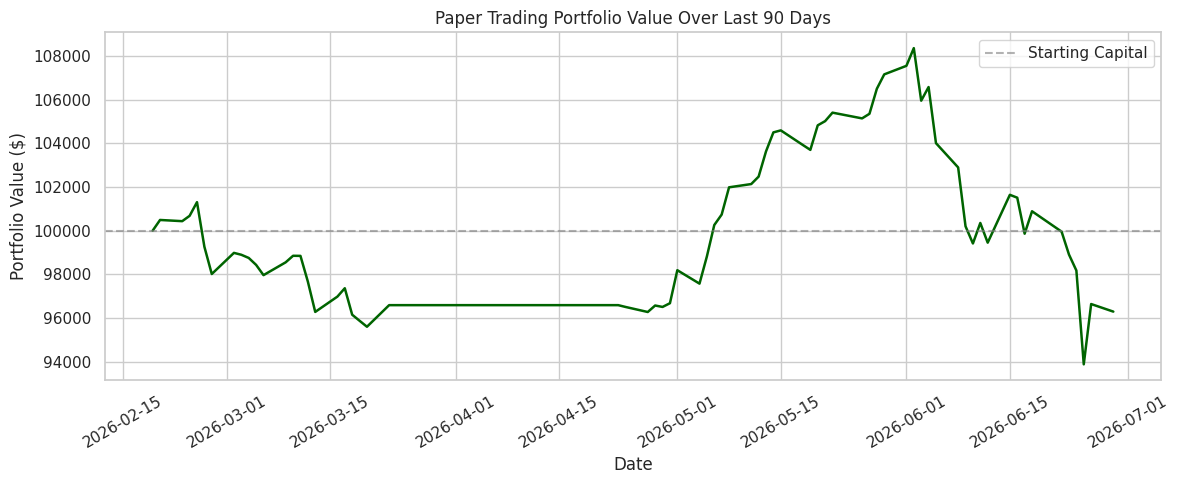

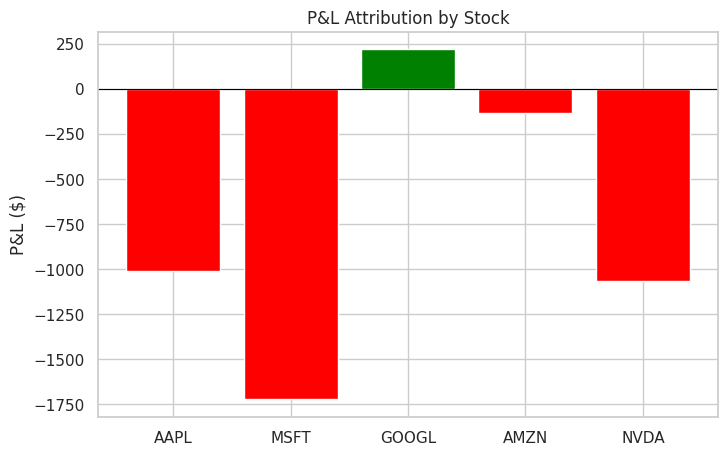

In [6]:
# ============================================
# MODULE 6: Paper Trading Simulator + Monthly Report
# ============================================

class PaperTradingSimulator:
    def __init__(self, initial_cash=100000):
        self.initial_cash = initial_cash
        self.cash = initial_cash
        self.holdings = {t: 0 for t in TICKERS}
        self.trade_log = []
        self.daily_values = []

    def execute_trade(self, ticker, signal, price, date, trade_size_pct=0.1):
        if signal == 'BUY':
            allocation = self.cash * trade_size_pct
            qty = int(allocation // price)
            if qty > 0:
                self.cash -= qty * price
                self.holdings[ticker] += qty
                self.trade_log.append({'date': date, 'ticker': ticker, 'action': 'BUY',
                                        'qty': qty, 'price': price, 'value': qty * price})
        elif signal == 'SELL' and self.holdings[ticker] > 0:
            qty = self.holdings[ticker]
            self.cash += qty * price
            self.holdings[ticker] = 0
            self.trade_log.append({'date': date, 'ticker': ticker, 'action': 'SELL',
                                    'qty': qty, 'price': price, 'value': qty * price})

    def portfolio_value(self, prices_dict):
        holdings_value = sum(self.holdings[t] * prices_dict.get(t, 0) for t in self.holdings)
        return self.cash + holdings_value

# ---- Run simulation over the last 90 days using SMA crossover + RSI signals ----
sim = PaperTradingSimulator(initial_cash=100000)
sim_days = 90

dates = stock_data[TICKERS[0]]['Date'].iloc[-sim_days:].reset_index(drop=True)

for i in range(len(dates)):
    day_prices = {}
    for ticker in TICKERS:
        df = stock_data[ticker]
        idx = len(df) - sim_days + i
        if idx < 50:  # need enough history for SMA_50
            continue
        row = df.iloc[idx]
        price = row['Close']
        day_prices[ticker] = price

        signal = 'BUY' if row['SMA_20'] > row['SMA_50'] and row['RSI'] < 70 else \
                 'SELL' if row['SMA_20'] < row['SMA_50'] and row['RSI'] > 30 else 'HOLD'
        sim.execute_trade(ticker, signal, price, row['Date'])

    sim.daily_values.append({'date': dates.iloc[i], 'value': sim.portfolio_value(day_prices)})

# ---- Performance Report ----
values_df = pd.DataFrame(sim.daily_values)
final_value = values_df['value'].iloc[-1]
total_return_pct = (final_value - sim.initial_cash) / sim.initial_cash * 100

print("=" * 60)
print("PAPER TRADING - 90 DAY PERFORMANCE REPORT")
print("=" * 60)
print(f"Starting Capital:     ${sim.initial_cash:,.2f}")
print(f"Ending Portfolio Value: ${final_value:,.2f}")
print(f"Total Return:          {total_return_pct:+.2f}%")
print(f"Total Trades Executed: {len(sim.trade_log)}")
print(f"Cash Remaining:        ${sim.cash:,.2f}")

# ---- Attribution Analysis: which stocks contributed most to returns ----
trade_log_df = pd.DataFrame(sim.trade_log)
print("\n--- Attribution Analysis (P&L by Stock) ---")
attribution = {}
for ticker in TICKERS:
    ticker_trades = trade_log_df[trade_log_df['ticker'] == ticker]
    buys = ticker_trades[ticker_trades['action'] == 'BUY']['value'].sum()
    sells = ticker_trades[ticker_trades['action'] == 'SELL']['value'].sum()
    remaining_value = sim.holdings[ticker] * stock_data[ticker]['Close'].iloc[-1]
    pnl = (sells + remaining_value) - buys
    attribution[ticker] = pnl
    print(f"  {ticker}: P&L contribution = ${pnl:+,.2f}  "
          f"({'gained' if pnl > 0 else 'reduced'} portfolio value)")

best = max(attribution, key=attribution.get)
worst = min(attribution, key=attribution.get)
print(f"\nBest contributor: {best} (${attribution[best]:+,.2f})")
print(f"Worst contributor: {worst} (${attribution[worst]:+,.2f})")

# ---- Plot portfolio value over time ----
plt.figure(figsize=(12, 5))
plt.plot(values_df['date'], values_df['value'], linewidth=1.8, color='darkgreen')
plt.axhline(sim.initial_cash, color='gray', linestyle='--', alpha=0.6, label='Starting Capital')
plt.title('Paper Trading Portfolio Value Over Last 90 Days')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---- Attribution bar chart ----
plt.figure(figsize=(8, 5))
colors = ['green' if v > 0 else 'red' for v in attribution.values()]
plt.bar(attribution.keys(), attribution.values(), color=colors)
plt.title('P&L Attribution by Stock')
plt.ylabel('P&L ($)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()